# Deep Learning Architecture Development with PyTorch
### A Workshop for AIMS Students

This notebook walks through the core concepts of deep learning architecture design using PyTorch. We progress from a single neuron to modern architectural patterns used in practice.

**Topics covered:**
1. The building block: a single neuron
2. Fully connected (feedforward) networks
3. Activation functions and their role
4. Training loop mechanics
5. Convolutional Neural Networks (CNNs)
6. Residual connections (ResNet-style)
7. Normalization and regularization techniques
8. Putting it together: a modular design pattern


## 0. Setup and Imports

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')

Using device: cpu
PyTorch version: 2.11.0+cpu


---
## 1. The Single Neuron

A neuron computes a weighted sum of its inputs, adds a bias, then passes the result through an activation function:

$$y = \sigma\left(\sum_{i} w_i x_i + b\right)$$

In PyTorch, `nn.Linear(in, out)` implements this linear part for a whole layer at once.

In [ ]:
# create a neuron with 4 inputs and 1 output using nn.Linear

In [22]:
# A single neuron: 3 inputs -> 1 output
neuron = nn.Linear(in_features=3, out_features=1)

In [21]:
print('Initialization weights:\n', neuron.weight.data)
print('Initialization:  ', neuron.bias.data)

Initialization weights:
 tensor([[-0.1265,  0.1165, -0.2811]])
Initialization:   tensor([0.3391])


In [23]:
print('Initialization weights:\n', neuron.weight.data)
print('Initialization:  ', neuron.bias.data)

Initialization weights:
 tensor([[3.5781e-04, 1.7393e-01, 4.5426e-01]])
Initialization:   tensor([0.3599])


In [20]:
neuron.weight.shape

torch.Size([1, 3])

In [7]:
print('Weight matrix shape:', neuron.weight.shape)   # (out, in)
print('Bias shape:          ', neuron.bias.shape)     # (out,)
print('Initialization weights:\n', neuron.weight.data)
print('Initialization:  ', neuron.bias.data)


Weight matrix shape: torch.Size([1, 3])
Bias shape:           torch.Size([1])
Initialization weights:
 tensor([[-0.1265,  0.1165, -0.2811]])
Initialization:   tensor([0.3391])


In [ ]:
x = torch.tensor([[1.0, 2.0, 3.0, 3]])

In [ ]:
neuron(x) #.item()  # Raw output (logits)

In [ ]:
# Forward pass with a random input
x = torch.tensor([[1.0, 2.0, 3.0]])
print(neuron(x).item())  # Raw output (logits)
output = torch.sigmoid(neuron(x))


print('\nInput:', x)
print('Neuron output (after sigmoid):', output.item())

-0.3976815938949585

Input: tensor([[1., 2., 3.]])
Neuron output (after sigmoid): 0.4018695056438446


---
## 2. Activation Functions

Activation functions introduce non-linearity. Without them, stacking linear layers is equivalent to a single linear transformation.

Common choices:
- **Sigmoid**: squashes output to (0, 1); suffers from vanishing gradients in deep nets
- **Tanh**: squashes to (-1, 1); zero-centered but still vanishes
- **ReLU**: fast, simple, avoids saturation for positive values; can produce dead neurons
- **GELU**: smooth approximation used in Transformers

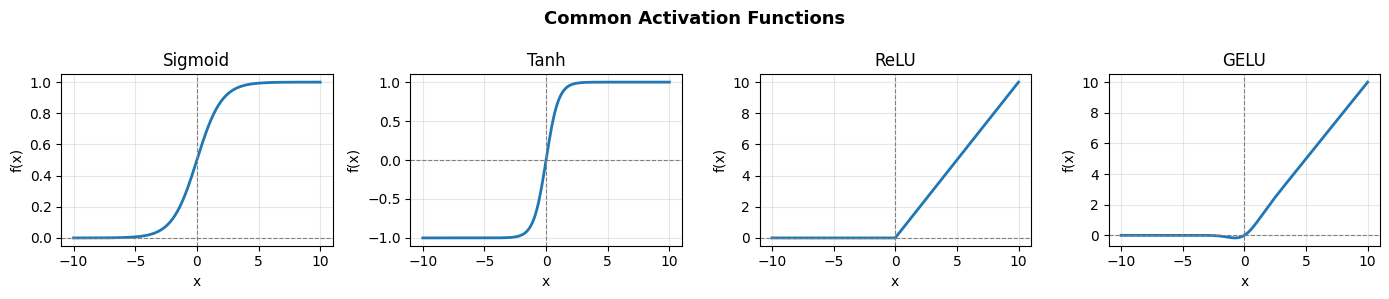

In [10]:
x_range = torch.linspace(-10, 10, 200)

activations = {
    'Sigmoid': torch.sigmoid(x_range),
    'Tanh': torch.tanh(x_range),
    'ReLU': F.relu(x_range),
    'GELU': F.gelu(x_range),
}

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, (name, values) in zip(axes, activations.items()):
    ax.plot(x_range.numpy(), values.detach().numpy(), linewidth=2)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_title(name)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.grid(True, alpha=0.3)

plt.suptitle('Common Activation Functions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Fully Connected (Feedforward) Network

A multilayer perceptron (MLP) stacks linear layers with activations in between. We define it using `nn.Module`, the base class for all PyTorch models.

In [ ]:
class MLP(nn.Module):

In [24]:
class MLP(nn.Module):
    """
    A simple feedforward network with configurable hidden layers.
    
    Args:
        input_dim  : number of input features
        hidden_dims: list of hidden layer widths
        output_dim : number of output classes
        dropout_p  : dropout probability applied after each hidden layer
    """
    
    def __init__(self, input_dim, hidden_dims, output_dim, dropout_p=0.0):
        super().__init__()
        
        layers = []
        in_dim = input_dim #20

        #[36, 16]
        for h in hidden_dims: 
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            in_dim = h
            
        layers.append(nn.Linear(in_dim, output_dim)) #output layer (no activation)
        
        # nn.Sequential chains the layers in order
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)


In [18]:
mlp = MLP(input_dim=784, hidden_dims=[256, 128], output_dim=10, dropout_p=0.2)
print(mlp)

MLP(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [25]:
# Count parameters
total_params = sum(p.numel() for p in mlp.parameters())
trainable_params = sum(p.numel() for p in mlp.parameters() if p.requires_grad)
print(f'\nTotal parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')


Total parameters:     235,146
Trainable parameters: 235,146


In [19]:
help(mlp.train())

Help on MLP in module __main__ object:

class MLP(torch.nn.modules.module.Module)
 |  MLP(input_dim, hidden_dims, output_dim, dropout_p=0.0)
 |
 |  A simple feedforward network with configurable hidden layers.
 |
 |  Args:
 |      input_dim  : number of input features
 |      hidden_dims: list of hidden layer widths
 |      output_dim : number of output classes
 |      dropout_p  : dropout probability applied after each hidden layer
 |
 |  Method resolution order:
 |      MLP
 |      torch.nn.modules.module.Module
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __init__(self, input_dim, hidden_dims, output_dim, dropout_p=0.0)
 |      Initialize internal Module state, shared by both nn.Module and ScriptModule.
 |
 |  forward(self, x)
 |      Define the computation performed at every call.
 |
 |      Should be overridden by all subclasses.
 |
 |      .. note::
 |          Although the recipe for forward pass needs to be defined within
 |          this function, one should cal

---
## 4. The Training Loop

Training consists of:
1. **Forward pass**: compute predictions
2. **Compute loss**: measure error against labels
3. **Backward pass**: compute gradients via backpropagation
4. **Optimizer step**: update weights
5. **Zero gradients**: reset accumulated gradients

We demonstrate on a synthetic binary classification task.

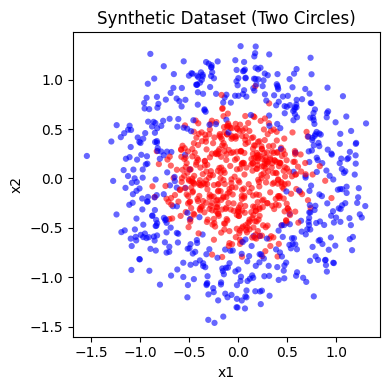

In [27]:
# --- Synthetic dataset: two concentric circles ---
from sklearn.datasets import make_circles

X_np, y_np = make_circles(n_samples=1000, noise=0.2, factor=0.4, random_state=42)
X = torch.FloatTensor(X_np)
y = torch.LongTensor(y_np)

# Train / validation split
n_train = 800
X_train, y_train = X[:n_train], y[:n_train]
X_val,   y_val   = X[n_train:], y[n_train:]

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val,   y_val),   batch_size=64)

plt.figure(figsize=(4, 4))
plt.scatter(X_np[:, 0], X_np[:, 1], c=y_np, cmap='bwr', alpha=0.6, edgecolors='none', s=20)
plt.title('Synthetic Dataset (Two Circles)')
plt.xlabel('x1'); plt.ylabel('x2')
plt.tight_layout()
plt.show()

In [6]:
y

tensor([1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1,
        0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1,
        0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0,
        1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0,
        1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1,
        0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1,
        1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0,
        1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
        0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
        0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0,
        0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0,

In [7]:
X.shape, y.shape

(torch.Size([1000, 2]), torch.Size([1000]))

In [17]:
X[0]

tensor([0.3260, 0.1804])

In [28]:
def train_model(model, train_loader, val_loader, epochs=50, lr=1e-3):
    """
    Generic training loop.
    Returns dictionaries of train/val loss and accuracy per epoch.
    """
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    for epoch in range(epochs):
        # --- Training ---
        model.train()
        train_loss, train_correct = 0.0, 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()           # 1. clear old gradients
            logits = model(X_batch)         # 2. forward pass
            loss = criterion(logits, y_batch)  # 3. compute loss
            loss.backward()                 # 4. backpropagate
            optimizer.step()               # 5. update weights
            
            train_loss += loss.item() * len(y_batch)
            train_correct += (logits.argmax(1) == y_batch).sum().item()
        
        # --- Validation ---
        model.eval()
        val_loss, val_correct = 0.0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                logits = model(X_batch)
                loss = criterion(logits, y_batch)
                val_loss += loss.item() * len(y_batch)
                val_correct += (logits.argmax(1) == y_batch).sum().item()
        
        n_train = len(train_loader.dataset)
        n_val   = len(val_loader.dataset)
        history['train_loss'].append(train_loss / n_train)
        history['val_loss'].append(val_loss / n_val)
        history['train_acc'].append(train_correct / n_train)
        history['val_acc'].append(val_correct / n_val)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | "
                  f"Train Loss: {history['train_loss'][-1]:.4f} | "
                  f"Val Acc: {history['val_acc'][-1]:.3f}")
    
    return history




In [29]:
# Train a small MLP on the circles dataset
mlp_small = MLP(input_dim=2, hidden_dims=[32, 32], output_dim=2, dropout_p=0.0)
history = train_model(mlp_small, train_loader, val_loader, epochs=60, lr=1e-3)

Epoch  10/60 | Train Loss: 0.3610 | Val Acc: 0.910
Epoch  20/60 | Train Loss: 0.2158 | Val Acc: 0.935
Epoch  30/60 | Train Loss: 0.1961 | Val Acc: 0.930
Epoch  40/60 | Train Loss: 0.1949 | Val Acc: 0.935
Epoch  50/60 | Train Loss: 0.1885 | Val Acc: 0.935
Epoch  60/60 | Train Loss: 0.1903 | Val Acc: 0.940


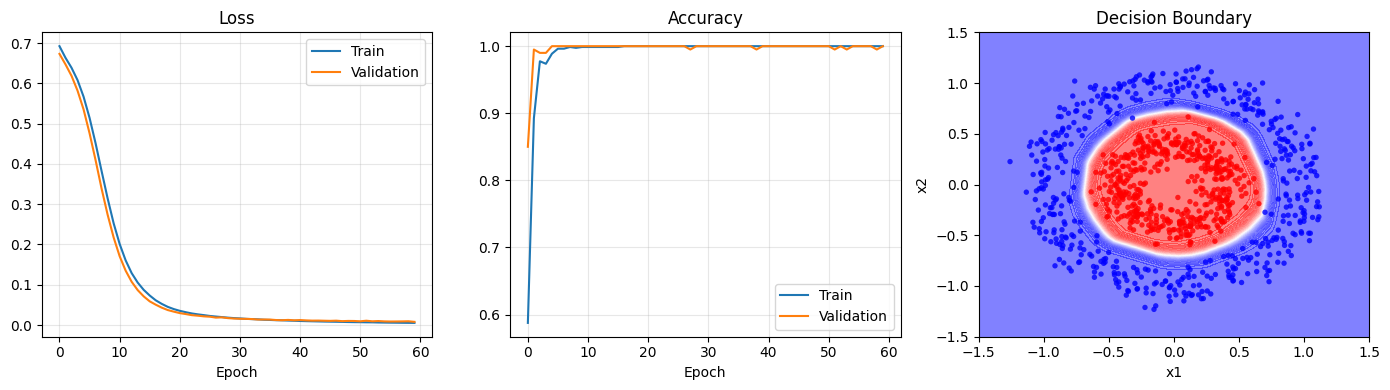

In [20]:
# Plot training curves and decision boundary
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Loss curve
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'],   label='Validation')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'],   label='Validation')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Decision boundary
xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 300), np.linspace(-1.5, 1.5, 300))
grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
mlp_small.eval()
with torch.no_grad():
    probs = torch.softmax(mlp_small(grid), dim=1)[:, 1].numpy()
probs = probs.reshape(xx.shape)

axes[2].contourf(xx, yy, probs, levels=50, cmap='bwr', alpha=0.5)
axes[2].scatter(X_np[:, 0], X_np[:, 1], c=y_np, cmap='bwr', s=15, edgecolors='none', alpha=0.8)
axes[2].set_title('Decision Boundary')
axes[2].set_xlabel('x1'); axes[2].set_ylabel('x2')

plt.tight_layout()
plt.show()

---
## 5. Convolutional Neural Networks (CNNs)

Convolutions exploit spatial structure in data (images, signals). A `Conv2d` layer applies a set of learnable filters that slide over the input, sharing weights across spatial positions.

Key concepts:
- **Kernel size**: spatial extent of each filter
- **Stride**: step size when sliding the filter
- **Padding**: zero-pad input to control output spatial size
- **Channels**: depth dimension; `Conv2d(in_channels, out_channels, kernel_size)`

In [ ]:
# Visualize what a convolution does to a small image
# We create a simple edge-detection filter manually

img = torch.zeros(1, 1, 8, 8)
img[0, 0, 2:6, 2:6] = 1.0   # white square in center

# Sobel-like horizontal edge filter
edge_filter = torch.tensor([[[[1., 2., 1.],
                               [0., 0., 0.],
                               [-1., -2., -1.]]]])

conv = nn.Conv2d(1, 1, kernel_size=3, padding=1, bias=False)
conv.weight.data = edge_filter

with torch.no_grad():
    feature_map = conv(img)

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(img[0, 0].numpy(), cmap='gray'); axes[0].set_title('Input Image')
axes[1].imshow(edge_filter[0, 0].numpy(), cmap='RdBu'); axes[1].set_title('Edge Filter (kernel)')
axes[2].imshow(feature_map[0, 0].detach().numpy(), cmap='RdBu'); axes[2].set_title('Output Feature Map')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
class SimpleCNN(nn.Module):
    """
    A small CNN for image classification.
    Input: (B, 1, 28, 28)  e.g., grayscale 28x28 images
    """
    def __init__(self, num_classes=10):
        super().__init__()
        
        # Feature extractor: convolutional blocks
        self.features = nn.Sequential(
            # Block 1: 1 -> 32 channels, 28x28 -> 14x14
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),           # halve spatial dims

            # Block 2: 32 -> 64 channels, 14x14 -> 7x7
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        
        # Classifier: flatten then fully connected
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes),
        )
    
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


cnn = SimpleCNN(num_classes=10)
print(cnn)

# Shape trace
dummy = torch.zeros(1, 1, 28, 28)
with torch.no_grad():
    print('\nShape after features :', cnn.features(dummy).shape)
    print('Output shape         :', cnn(dummy).shape)
    
total = sum(p.numel() for p in cnn.parameters())
print(f'Total parameters: {total:,}')

---
## 6. Batch Normalization and Dropout

**Batch Normalization** (`nn.BatchNorm2d` / `nn.BatchNorm1d`):
- Normalizes each mini-batch to zero mean and unit variance
- Reduces internal covariate shift, enabling higher learning rates
- Applied before or after the activation (convention varies)

**Dropout** (`nn.Dropout`):
- Randomly zeroes a fraction `p` of activations during training
- Acts as an implicit ensemble of many smaller networks
- Disabled at inference (`model.eval()` handles this automatically)

In [ ]:
# Demonstrate BatchNorm behavior: before vs after normalization
torch.manual_seed(0)
raw = torch.randn(64, 16) * 5 + 3   # shifted, scaled data

bn = nn.BatchNorm1d(16)
bn.train()
normalized = bn(raw)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(raw.detach().numpy().ravel(), bins=40, color='steelblue')
axes[0].set_title(f'Before BatchNorm  (mean={raw.mean():.2f}, std={raw.std():.2f})')
axes[1].hist(normalized.detach().numpy().ravel(), bins=40, color='darkorange')
axes[1].set_title(f'After BatchNorm  (mean={normalized.mean():.2f}, std={normalized.std():.2f})')
for ax in axes: ax.set_xlabel('Activation value'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Demonstrate Dropout: training vs eval mode
dropout = nn.Dropout(p=0.5)
x_demo = torch.ones(1, 10)

dropout.train()
print('Training mode (dropout active) :', dropout(x_demo))
dropout.eval()
print('Eval mode    (dropout disabled):', dropout(x_demo))

---
## 7. Residual Connections (Skip Connections)

Introduced by He et al. (2015) in ResNet. Instead of learning the mapping $H(x)$, the layer learns the **residual** $F(x) = H(x) - x$, so the output is:

$$\text{output} = F(x) + x$$

Benefits:
- Gradients flow directly through the skip connection, avoiding vanishing gradients
- Identity mapping is easy to learn (set weights to zero)
- Enables training of very deep networks (100+ layers)

In [ ]:
class ResidualBlock(nn.Module):
    """
    A standard residual block with two 3x3 convolutions and a skip connection.
    If in_channels != out_channels, a 1x1 convolution is used to match dimensions.
    """
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)
        
        # Projection shortcut: align dimensions when they change
        self.shortcut = nn.Identity()
        if in_channels != out_channels or stride != 1:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
    
    def forward(self, x):
        residual = self.shortcut(x)          # skip path
        
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        
        out = out + residual                 # add skip connection
        return F.relu(out)


# Quick shape check
block = ResidualBlock(in_channels=64, out_channels=128, stride=2)
x_test = torch.zeros(2, 64, 16, 16)
print('Input shape: ', x_test.shape)
print('Output shape:', block(x_test).shape)   # stride=2 halves spatial dims

In [ ]:
class SmallResNet(nn.Module):
    """
    A small ResNet-style classifier for 32x32 images (e.g., CIFAR-like).
    """
    def __init__(self, num_classes=10):
        super().__init__()
        
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )
        
        self.layer1 = ResidualBlock(32, 32)
        self.layer2 = ResidualBlock(32, 64, stride=2)   # 32x32 -> 16x16
        self.layer3 = ResidualBlock(64, 128, stride=2)  # 16x16 -> 8x8
        
        self.pool = nn.AdaptiveAvgPool2d(1)  # global average pooling -> (B, 128, 1, 1)
        self.fc   = nn.Linear(128, num_classes)
    
    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.pool(x).flatten(1)
        return self.fc(x)


resnet = SmallResNet(num_classes=10)
dummy_img = torch.zeros(4, 3, 32, 32)   # batch of 4 RGB 32x32 images
print('Output shape:', resnet(dummy_img).shape)
print(f'Total params: {sum(p.numel() for p in resnet.parameters()):,}')

---
## 8. Gradient Flow Visualization

One of the key diagnostic tools in deep learning is inspecting gradient magnitudes across layers. Vanishing gradients (magnitudes near zero) indicate layers are not learning effectively.

In [ ]:
def get_gradient_norms(model, loss):
    """Run backprop and collect gradient norms per named parameter."""
    loss.backward()
    grad_norms = {}
    for name, param in model.named_parameters():
        if param.grad is not None:
            grad_norms[name] = param.grad.norm().item()
    return grad_norms


# Compare gradient norms for ResNet (with skip connections) vs plain deep CNN
class PlainDeepCNN(nn.Module):
    """Same depth as SmallResNet but without residual connections."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1, bias=False), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1, bias=False), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1, bias=False), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1, bias=False), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1, bias=False), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1, bias=False), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(128, num_classes)
        )
    def forward(self, x): return self.layers(x)


def compute_grad_norms(ModelClass):
    torch.manual_seed(0)
    model = ModelClass()
    x = torch.randn(8, 3, 32, 32)
    y = torch.randint(0, 10, (8,))
    loss = nn.CrossEntropyLoss()(model(x), y)
    norms = get_gradient_norms(model, loss)
    return norms

resnet_grads = compute_grad_norms(SmallResNet)
plain_grads  = compute_grad_norms(PlainDeepCNN)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (name, grads) in zip(axes, [('SmallResNet (with skip connections)', resnet_grads),
                                      ('PlainDeepCNN (no skip connections)',  plain_grads)]):
    names  = list(grads.keys())
    values = list(grads.values())
    ax.bar(range(len(names)), values, color='steelblue', alpha=0.8)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=90, fontsize=7)
    ax.set_ylabel('Gradient norm')
    ax.set_title(name)
    ax.grid(True, alpha=0.3)

plt.suptitle('Gradient Norms: Residual vs Plain Network', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Learning Rate Schedulers

The learning rate is one of the most important hyperparameters. Schedulers adjust it during training:

- **StepLR**: decay by a factor every N epochs
- **CosineAnnealingLR**: smooth decay following a cosine curve
- **OneCycleLR**: warm-up then decay — often fastest to converge

In [ ]:
def get_lr_schedule(scheduler_class, **kwargs):
    """Simulate learning rate values for visualization."""
    dummy_model = nn.Linear(1, 1)
    opt = optim.SGD(dummy_model.parameters(), lr=0.1)
    scheduler = scheduler_class(opt, **kwargs)
    lrs = []
    for _ in range(100):
        lrs.append(opt.param_groups[0]['lr'])
        scheduler.step()
    return lrs


schedules = {
    'StepLR (step=20, gamma=0.5)': get_lr_schedule(optim.lr_scheduler.StepLR, step_size=20, gamma=0.5),
    'CosineAnnealingLR (T_max=100)': get_lr_schedule(optim.lr_scheduler.CosineAnnealingLR, T_max=100),
    'ExponentialLR (gamma=0.97)': get_lr_schedule(optim.lr_scheduler.ExponentialLR, gamma=0.97),
}

plt.figure(figsize=(10, 4))
for label, lrs in schedules.items():
    plt.plot(lrs, label=label, linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('Learning rate')
plt.title('Learning Rate Schedulers')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 10. Putting It All Together: A Modular Architecture Pattern

Good deep learning code is **modular and readable**. The pattern below separates concerns cleanly: backbone, neck, and head. This is the standard pattern in object detection, segmentation, and many modern architectures.

In [ ]:
class ConvBlock(nn.Module):
    """Reusable Conv -> BN -> Activation block."""
    def __init__(self, in_ch, out_ch, kernel=3, stride=1, activation=nn.ReLU):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel, stride=stride, padding=kernel // 2, bias=False),
            nn.BatchNorm2d(out_ch),
            activation()
        )
    def forward(self, x): return self.block(x)


class Backbone(nn.Module):
    """Feature extractor producing a rich spatial representation."""
    def __init__(self):
        super().__init__()
        self.stage1 = nn.Sequential(ConvBlock(3, 32), ResidualBlock(32, 32))
        self.stage2 = nn.Sequential(ConvBlock(32, 64, stride=2), ResidualBlock(64, 64))
        self.stage3 = nn.Sequential(ConvBlock(64, 128, stride=2), ResidualBlock(128, 128))
    
    def forward(self, x):
        c1 = self.stage1(x)
        c2 = self.stage2(c1)
        c3 = self.stage3(c2)
        return c1, c2, c3   # return multi-scale features


class ClassificationHead(nn.Module):
    """Takes the deepest feature map and outputs class logits."""
    def __init__(self, in_channels, num_classes, dropout_p=0.3):
        super().__init__()
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(dropout_p),
            nn.Linear(in_channels, num_classes)
        )
    def forward(self, features):
        _, _, c3 = features   # use only the deepest scale
        return self.head(c3)


class ModularClassifier(nn.Module):
    """Combines backbone and head into a complete classifier."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.backbone = Backbone()
        self.head     = ClassificationHead(128, num_classes)
    
    def forward(self, x):
        features = self.backbone(x)
        return self.head(features)


model = ModularClassifier(num_classes=10)
x_demo = torch.zeros(2, 3, 32, 32)
c1, c2, c3 = model.backbone(x_demo)
print('Multi-scale feature shapes:')
print(f'  Stage 1 (c1): {c1.shape}')
print(f'  Stage 2 (c2): {c2.shape}')
print(f'  Stage 3 (c3): {c3.shape}')
print('Final output   :', model(x_demo).shape)
print(f'Total params   : {sum(p.numel() for p in model.parameters()):,}')

---
## 11. Architecture Comparison Summary

The table below summarizes the architectures built in this workshop.

In [ ]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

architectures = [
    ('MLP (2 hidden layers)',     MLP(2, [32, 32], 2),          'Tabular / small input'),
    ('SimpleCNN',                 SimpleCNN(10),                 'Image (28x28 gray)'),
    ('SmallResNet',               SmallResNet(10),               'Image (32x32 RGB)'),
    ('ModularClassifier',         ModularClassifier(10),         'Image (32x32 RGB)'),
]

print(f'{'Architecture':<28} {'Parameters':>12}  {'Typical Use Case'}')
print('-' * 70)
for name, model, use_case in architectures:
    print(f'{name:<28} {count_params(model):>12,}  {use_case}')

---
## 12. Exercises

These exercises are designed to deepen your understanding of the concepts covered.

**Exercise 1 — Depth vs Width:**  
Compare classification accuracy on the circles dataset using (a) a wide shallow MLP `[256]` vs (b) a narrow deep MLP `[32, 32, 32, 32]`. Which generalizes better? Why might depth matter beyond simply increasing capacity?

**Exercise 2 — Ablation study:**  
Remove BatchNorm from `SimpleCNN`. Train both versions for 20 epochs. Plot their loss curves side by side and describe what you observe.

**Exercise 3 — Residual depth:**  
Add two more `ResidualBlock` stages to `SmallResNet` (i.e., `layer4` with 256 channels). Does the gradient norm plot change compared to the plain version?

**Exercise 4 — Optimizer comparison:**  
Train the same MLP on the circles dataset using (a) SGD with momentum=0.9, (b) Adam, and (c) RMSprop. Plot all three loss curves on a single figure.

**Exercise 5 — Custom activation:**  
Implement Swish ($f(x) = x \cdot \sigma(x)$) as a custom `nn.Module`. Swap it in place of ReLU in `SimpleCNN` and verify the output shapes are unchanged.

In [ ]:
# --- Exercise 5 starter: Swish activation ---

class Swish(nn.Module):
    """Swish activation: f(x) = x * sigmoid(x)"""
    def forward(self, x):
        # TODO: implement
        raise NotImplementedError

# Verify shape
# swish = Swish()
# out = swish(torch.randn(4, 32, 16, 16))
# print(out.shape)  # should be torch.Size([4, 32, 16, 16])

---
## Further Reading

- **PyTorch documentation**: https://pytorch.org/docs/stable/index.html
- He et al. (2015) — *Deep Residual Learning for Image Recognition* (ResNet)
- Ioffe & Szegedy (2015) — *Batch Normalization: Accelerating Deep Network Training*
- Goodfellow et al. — *Deep Learning* (textbook, available free online)
- cs231n.stanford.edu — Convolutional Neural Networks for Visual Recognition (course notes)